## Imports

In [3]:
!pip install lightgbm

   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 9.5 MB/s eta 0:00:00



[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import os
import time
import warnings
warnings.filterwarnings('ignore')

from sklearn.linear_model    import LogisticRegression
from sklearn.tree            import DecisionTreeClassifier, export_text, plot_tree
from sklearn.ensemble        import RandomForestClassifier, GradientBoostingClassifier, ExtraTreesClassifier
from sklearn.neighbors       import KNeighborsClassifier
from sklearn.naive_bayes     import GaussianNB
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing   import RobustScaler, label_binarize
from sklearn.metrics         import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, average_precision_score,
    f1_score, precision_score, recall_score,
    accuracy_score, matthews_corrcoef
)
from sklearn.calibration     import CalibratedClassifierCV
from imblearn.over_sampling  import SMOTE
import xgboost  as xgb
import lightgbm as lgb
from scipy import stats

sns.set_style('darkgrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size']      = 11

print("All libraries imported successfully!")
print(f"XGBoost  version : {xgb.__version__}")
print(f"LightGBM version : {lgb.__version__}")

All libraries imported successfully!
XGBoost  version : 3.3.0
LightGBM version : 4.6.0


## Load featured data

In [5]:
# ── Load the featured dataset saved from Feature Engineering notebook
# This has all 79 features already engineered
# NO need to redo any feature engineering here

df = pd.read_csv(r"C:\Users\tjain\Downloads\HI-Small_Trans.csv")

print("Featured dataset loaded!")
print(f"Shape          : {df.shape}")
print(f"Total features : {df.shape[1] - 1}")
print(f"Fraud rows     : {df['Is Laundering'].sum():,}")
print(f"Normal rows    : {(df['Is Laundering']==0).sum():,}")
print(f"Imbalance ratio: {(df['Is Laundering']==0).sum() // df['Is Laundering'].sum()}:1")
print(f"\nColumns:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2}. {col}")

Featured dataset loaded!
Shape          : (5078336, 32)
Total features : 31
Fraud rows     : 5,177
Normal rows    : 5,073,159
Imbalance ratio: 979:1

Columns:
   1. Hour
   2. Day
   3. DayOfWeek
   4. IsWeekend
   5. Sender Bank ID
   6. Receiver Bank ID
   7. is_cross_bank
   8. Sender_Account_Encoded
   9. Receiver_Account_Encoded
  10. is_self_transfer
  11. Amount Paid
  12. Amount Received
  13. amount_vs_account_median
  14. is_currency_mismatch
  15. is_amount_outlier_iqr
  16. is_amount_outlier_zscore
  17. is_account_level_outlier
  18. is_high_velocity
  19. outlier_score
  20. is_outlier
  21. txn_count_per_sender_hour
  22. txn_count_per_sender_day
  23. fmt_ACH
  24. fmt_Bitcoin
  25. fmt_Cash
  26. fmt_Cheque
  27. fmt_Credit Card
  28. fmt_Reinvestment
  29. fmt_Wire
  30. Payment_Currency_Encoded
  31. Receiving_Currency_Encoded
  32. Is Laundering


## Define your exact 79 features

In [6]:
# ── These are YOUR exact 79 features from Feature Engineering notebook
# Taken directly from your notebook output

FEATURE_COLS = [
    # Time features
    'Hour', 'Day', 'DayOfWeek', 'IsWeekend',

    # Bank features
    'Sender Bank ID', 'Receiver Bank ID',
    'Sender_Account_Encoded', 'Receiver_Account_Encoded',
    'Amount_Paid_Log',

    # Transaction flags
    'is_cross_bank', 'is_self_transfer', 'is_currency_mismatch',

    # Outlier features
    'is_outlier', 'outlier_score',
    'is_amount_outlier_iqr', 'is_amount_outlier_zscore',
    'is_account_level_outlier', 'is_high_velocity',

    # Velocity features
    'txn_count_per_sender_hour', 'txn_count_per_sender_day',
    'amount_vs_account_median',

    # Currency features
    'Payment_Currency_Encoded', 'Receiving_Currency_Encoded',

    # Advanced velocity
    'sender_txn_count_per_day', 'sender_txn_count_per_hour',
    'sender_total_amount_per_day', 'sender_unique_receivers_per_day',

    # Amount ratio features
    'amount_ratio_vs_sender_mean', 'amount_ratio_vs_sender_median',
    'sender_amount_zscore', 'is_sender_max_transaction',

    # Structuring features
    'is_round_amount', 'is_just_below_threshold',
    'is_structuring_pattern', 'avg_txn_size_today',

    # Network features
    'sender_unique_banks', 'receiver_unique_senders',
    'bank_pair_fraud_rate', 'is_first_time_transfer',
    'receiver_concentration',

    # Time pattern features
    'is_night_transaction', 'is_early_morning',
    'hour_deviation_from_usual', 'is_weekend_large_amount',
    'is_night_large_amount',

    # Currency and payment
    'is_same_currency', 'is_high_risk_format',

    # Composite score
    'composite_risk_score',

    # Unique sender/receiver counts
    'unique_senders_to_receiver', 'unique_receivers_from_sender',
    'sender_unique_banks_total', 'receiver_unique_banks_total',

    # Fan-in and fan-out
    'fan_in_score', 'fan_out_score',
    'fan_in_count', 'fan_out_count', 'fan_ratio',

    # Mule detection
    'mule_score', 'is_potential_mule',
    'account_amount_balance_ratio',

    # Sending to mule
    'is_sending_to_mule', 'receiver_mule_score',
    'amount_sent_to_mule', 'sender_total_sent_to_mules',
    'pct_transactions_to_mules',

    # Total transaction counts
    'sender_total_txn_count', 'receiver_total_txn_count',
    'sender_total_amount_sent', 'receiver_total_amount_received',
    'sender_avg_txn_amount', 'receiver_avg_txn_amount',
    'txn_count_ratio',
]

# Add fmt_ OHE columns
fmt_cols = [c for c in df.columns if c.startswith('fmt_')]
FEATURE_COLS = FEATURE_COLS + fmt_cols

# Keep only columns that actually exist in your dataset
FEATURE_COLS = [f for f in FEATURE_COLS if f in df.columns]

# Remove duplicates while preserving order
seen = set()
FEATURE_COLS = [f for f in FEATURE_COLS if not (f in seen or seen.add(f))]

X = df[FEATURE_COLS].fillna(0)
y = df['Is Laundering']

print(f"Features confirmed : {len(FEATURE_COLS)}")
print(f"X shape            : {X.shape}")
print(f"y shape            : {y.shape}")
print(f"Fraud              : {y.sum():,}")
print(f"Normal             : {(y==0).sum():,}")
print(f"\nfmt columns: {fmt_cols}")

Features confirmed : 29
X shape            : (5078336, 29)
y shape            : (5078336,)
Fraud              : 5,177
Normal             : 5,073,159

fmt columns: ['fmt_ACH', 'fmt_Bitcoin', 'fmt_Cash', 'fmt_Cheque', 'fmt_Credit Card', 'fmt_Reinvestment', 'fmt_Wire']


## Train test and split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size    = 0.2,
    random_state = 42,
    stratify     = y        # preserve fraud ratio in both sets
)

print("Train/Test Split done!")
print(f"\nX_train shape  : {X_train.shape}")
print(f"X_test shape   : {X_test.shape}")
print(f"Fraud in train : {y_train.sum():,} ({y_train.mean()*100:.3f}%)")
print(f"Fraud in test  : {y_test.sum():,}  ({y_test.mean()*100:.3f}%)")

Train/Test Split done!

X_train shape  : (4062668, 29)
X_test shape   : (1015668, 29)
Fraud in train : 4,142 (0.102%)
Fraud in test  : 1,035  (0.102%)


## Scale features 

In [8]:
# RobustScaler — uses median and IQR
# Resistant to extreme outlier values in AML data
# CRITICAL: fit only on train, transform both

scaler = RobustScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=FEATURE_COLS
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=FEATURE_COLS
)

print("RobustScaler applied!")
print(f"X_train_scaled : {X_train_scaled.shape}")
print(f"X_test_scaled  : {X_test_scaled.shape}")

RobustScaler applied!
X_train_scaled : (4062668, 29)
X_test_scaled  : (1015668, 29)


## SMOTE

In [9]:
print("Before SMOTE:")
print(f"  Normal : {(y_train==0).sum():,}")
print(f"  Fraud  : {(y_train==1).sum():,}")
print(f"  Ratio  : {(y_train==0).sum()//(y_train==1).sum()}:1")

smote = SMOTE(
    sampling_strategy = 0.3,
    random_state      = 42,
    k_neighbors       = 5,
)

print("\nRunning SMOTE — please wait...")
X_train_res, y_train_res = smote.fit_resample(X_train_scaled, y_train)

print(f"\nAfter SMOTE:")
print(f"  Normal : {(y_train_res==0).sum():,}")
print(f"  Fraud  : {(y_train_res==1).sum():,}")
print(f"  Shape  : {X_train_res.shape}")

scale_pos_weight = (y_train_res==0).sum() / (y_train_res==1).sum()
print(f"\nscale_pos_weight for XGBoost/LightGBM : {scale_pos_weight:.2f}")

Before SMOTE:
  Normal : 4,058,526
  Fraud  : 4,142
  Ratio  : 979:1

Running SMOTE — please wait...

After SMOTE:
  Normal : 4,058,526
  Fraud  : 1,217,557
  Shape  : (5276083, 29)

scale_pos_weight for XGBoost/LightGBM : 3.33


## Evaluate helper function

In [10]:
def evaluate_model(name, model, X_tr, y_tr, X_te, y_te):
    """
    Train and evaluate any sklearn-compatible model.
    Returns dictionary of all metrics + model object.
    """
    print(f"\n{'='*60}")
    print(f"  Training: {name}")
    print(f"{'='*60}")

    # Time training
    t0 = time.time()
    model.fit(X_tr, y_tr)
    train_time = round(time.time() - t0, 1)

    # Predictions
    y_pred = model.predict(X_te)

    # Probabilities
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_te)[:, 1]
    elif hasattr(model, 'decision_function'):
        raw = model.decision_function(X_te)
        y_proba = (raw - raw.min()) / (raw.max() - raw.min() + 1e-9)
    else:
        y_proba = y_pred.astype(float)

    # Compute metrics
    auc_roc   = roc_auc_score(y_te, y_proba)
    auc_pr    = average_precision_score(y_te, y_proba)
    f1        = f1_score(y_te, y_pred, zero_division=0)
    prec      = precision_score(y_te, y_pred, zero_division=0)
    rec       = recall_score(y_te, y_pred)
    acc       = accuracy_score(y_te, y_pred)
    mcc       = matthews_corrcoef(y_te, y_pred)
    cm        = confusion_matrix(y_te, y_pred)
    tn, fp, fn, tp = cm.ravel()

    print(f"  Train time   : {train_time}s")
    print(f"  AUC-ROC      : {auc_roc:.4f}")
    print(f"  AUC-PR       : {auc_pr:.4f}")
    print(f"  Recall       : {rec:.4f}  ← {tp} caught / {y_te.sum()} fraud")
    print(f"  Precision    : {prec:.4f}")
    print(f"  F1 Score     : {f1:.4f}")
    print(f"  MCC          : {mcc:.4f}")
    print(f"  Fraud caught : {tp} | Missed: {fn} | False alarms: {fp}")

    return {
        'model_name'      : name,
        'model_object'    : model,
        'y_proba'         : y_proba,
        'y_pred'          : y_pred,
        'auc_roc'         : round(auc_roc,  4),
        'auc_pr'          : round(auc_pr,   4),
        'f1'              : round(f1,        4),
        'precision'       : round(prec,     4),
        'recall'          : round(rec,      4),
        'accuracy'        : round(acc,      4),
        'mcc'             : round(mcc,      4),
        'train_time_s'    : train_time,
        'true_positives'  : int(tp),
        'false_positives' : int(fp),
        'false_negatives' : int(fn),
        'true_negatives'  : int(tn),
        'confusion_matrix': cm
    }

print("Evaluation function ready!")

Evaluation function ready!


## Model-01: Logistic Regression (Baseline)

In [11]:
# ──────────────────────────────────────────────────────────────
# Logistic Regression (Baseline Model)
# Purpose: Compare with XGBoost to demonstrate the benefit of
# advanced ensemble learning on AML detection.
# ──────────────────────────────────────────────────────────────

from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(
    penalty='l2',              # Ridge regularization
    C=1.0,                     # Regularization strength
    solver='lbfgs',            # Efficient optimizer
    max_iter=2000,             # More iterations for convergence
    class_weight='balanced',   # Handle class imbalance
    random_state=42
)

print("="*60)
print("Training Logistic Regression...")
print("="*60)

result_lr = evaluate_model(
    name="Logistic Regression",
    model=lr_model,
    X_tr=X_train_res,
    y_tr=y_train_res,
    X_te=X_test_scaled,
    y_te=y_test
)

print("\nLogistic Regression training completed successfully!")

Training Logistic Regression...

  Training: Logistic Regression
  Train time   : 860.5s
  AUC-ROC      : 0.9505
  AUC-PR       : 0.0149
  Recall       : 0.9372  ← 970 caught / 1035 fraud
  Precision    : 0.0061
  F1 Score     : 0.0121
  MCC          : 0.0685
  Fraud caught : 970 | Missed: 65 | False alarms: 158508

Logistic Regression training completed successfully!


## Model-02: Desicion tree


  Training: Decision Tree (depth=5)
  Train time   : 63.7s
  AUC-ROC      : 0.9554
  AUC-PR       : 0.0255
  Recall       : 0.8570  ← 887 caught / 1035 fraud
  Precision    : 0.0098
  F1 Score     : 0.0194
  MCC          : 0.0860
  Fraud caught : 887 | Missed: 148 | False alarms: 89748


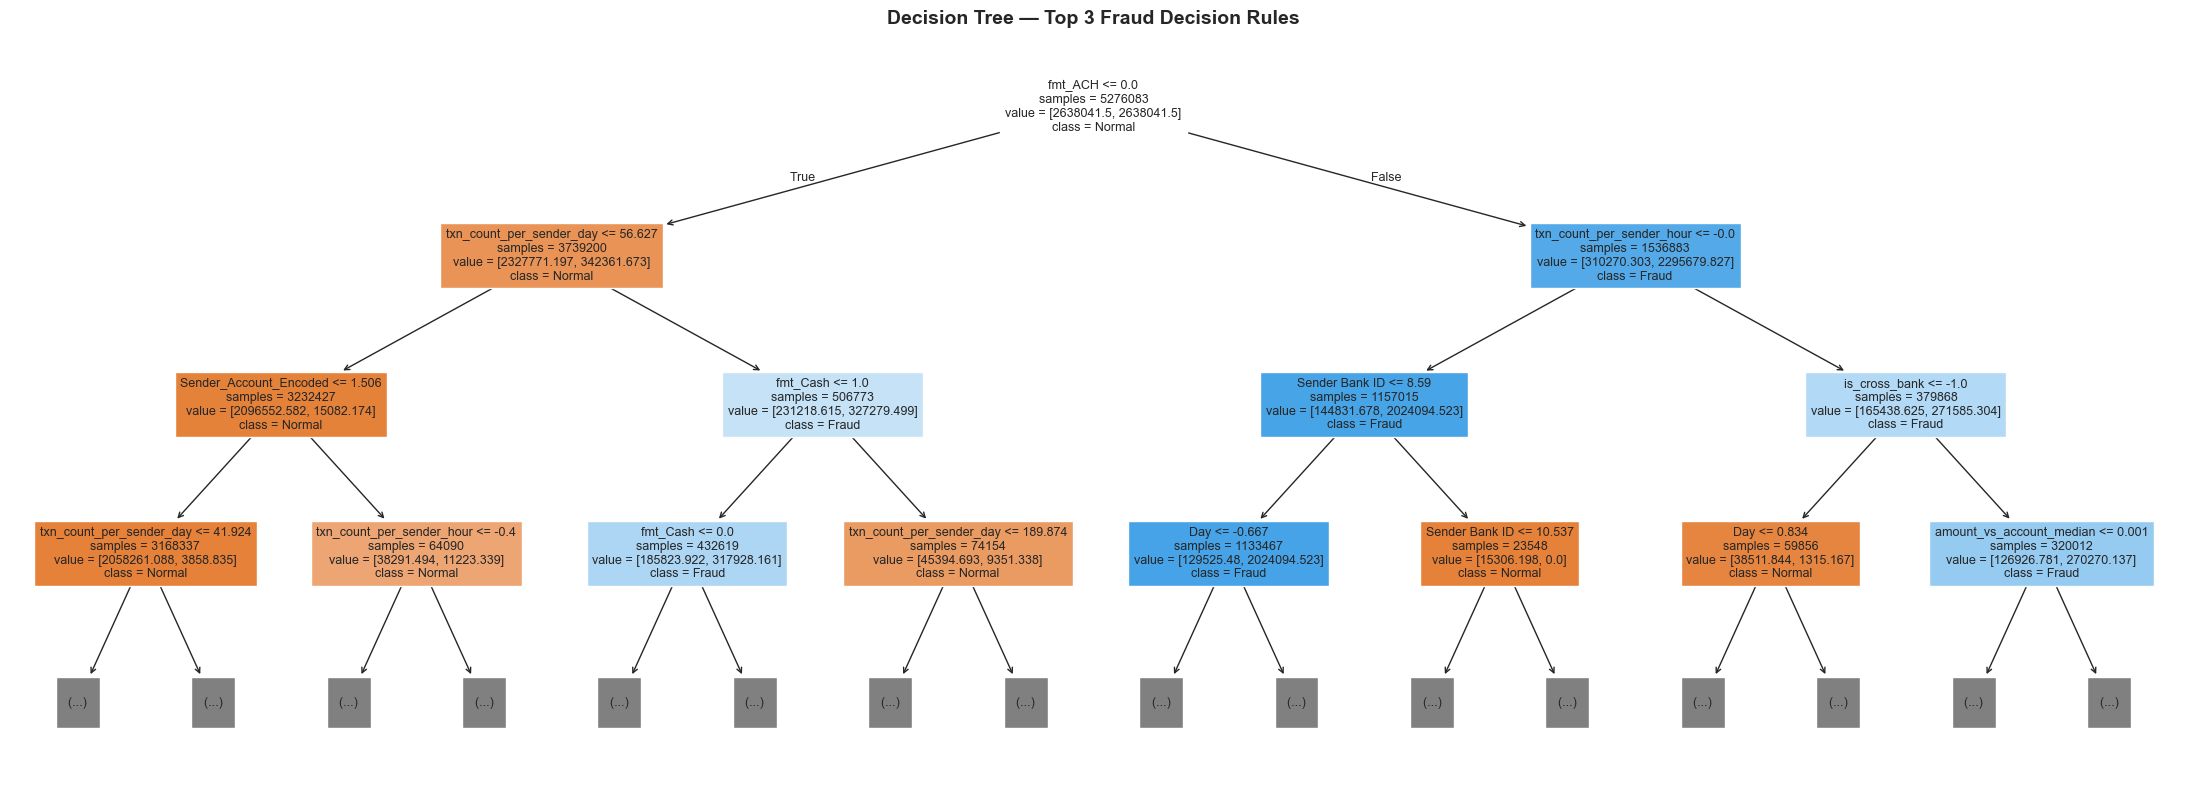


Top decision rules (text format):
|--- fmt_ACH <= 0.00
|   |--- txn_count_per_sender_day <= 56.63
|   |   |--- Sender_Account_Encoded <= 1.51
|   |   |   |--- txn_count_per_sender_day <= 41.92
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- txn_count_per_sender_day >  41.92
|   |   |   |   |--- truncated branch of depth 2
|   |   |--- Sender_Account_Encoded >  1.51
|   |   |   |--- txn_count_per_sender_hour <= -0.40
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- txn_count_per_sender_hour >  -0.40
|   |   |   |   |--- truncated branch of depth 2
|   |--- txn_count_per_sender_day >  56.63
|   |   |--- fmt_Cash <= 1.00
|   |   |   |--- fmt_Cash <= 0.00
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- fmt_Cash >  0.00
|   |   |   |   |--- class: 1
|   |   |--- fmt_Cash >  1.00
|   |   |   |--- txn_count_per_sender_day <= 189.87
|   |   |   |   |--- truncated branch of depth 2
|   |   |   |--- txn_count_per_sender_day >  189.87
|   |   

In [13]:
# ── WHY DECISION TREE ─────────────────────────────────────
# Splits data by asking YES/NO questions about features
# "Is Amount_Paid_Log > 12.5?" → Yes → fraud branch
# Fully interpretable — you can visualise the exact rules
# We use depth=5 to keep it readable (not overfitted)
# A single tree OVERFITS on 5M rows at full depth
# This is why Random Forest (100 trees averaged) beats it
# ─────────────────────────────────────────────────────────

dt_model = DecisionTreeClassifier(
    max_depth        = 5,          # shallow = interpretable, no overfit
    min_samples_leaf = 100,        # each leaf needs 100 transactions
    class_weight     = 'balanced',
    random_state     = 42,
    criterion        = 'gini'      # gini impurity for splitting
)

result_dt = evaluate_model(
    name = 'Decision Tree (depth=5)',
    model = dt_model,
    X_tr  = X_train_res,
    y_tr  = y_train_res,
    X_te  = X_test_scaled,
    y_te  = y_test
)

# ── Visualise the decision tree (top 3 levels) ────────────
plt.figure(figsize=(22, 8))
plot_tree(
    dt_model,
    feature_names = FEATURE_COLS,
    class_names   = ['Normal', 'Fraud'],
    filled        = True,
    max_depth     = 3,           # show only top 3 levels for clarity
    fontsize      = 9,
    impurity      = False
)
plt.title('Decision Tree — Top 3 Fraud Decision Rules', fontweight='bold', fontsize=14)
plt.tight_layout()
plt.savefig('decision_tree_rules.png', dpi=120, bbox_inches='tight')
plt.show()

# Print text rules
print("\nTop decision rules (text format):")
print(export_text(dt_model, feature_names=FEATURE_COLS, max_depth=3))

## Model-03: Random Forest

In [14]:
# ── WHY RANDOM FOREST ─────────────────────────────────────
# Builds 200 decision trees INDEPENDENTLY (parallel)
# Each tree sees a random subset of rows and features
# Final prediction = majority vote of all 200 trees
# Because trees are built on different random subsets
# they make DIFFERENT errors — averaging cancels errors out
# This is called BAGGING (Bootstrap AGGregatING)
# Compared to XGBoost (sequential) vs RF (parallel)
# Different errors caught = complementary models
# ─────────────────────────────────────────────────────────

rf_model = RandomForestClassifier(
    n_estimators     = 200,        # 200 trees
    max_depth        = 12,         # deep enough to learn patterns
    min_samples_leaf = 50,
    max_features     = 'sqrt',     # each tree sees sqrt(n_features)
    class_weight     = 'balanced',
    random_state     = 42,
    n_jobs           = -1,         # use all CPU cores
    oob_score        = True        # out-of-bag score estimate
)

result_rf = evaluate_model(
    name = 'Random Forest (200 trees)',
    model = rf_model,
    X_tr  = X_train_res,
    y_tr  = y_train_res,
    X_te  = X_test_scaled,
    y_te  = y_test
)

print(f"\nOut-of-bag score : {rf_model.oob_score_:.4f}")


  Training: Random Forest (200 trees)
  Train time   : 841.5s
  AUC-ROC      : 0.9687
  AUC-PR       : 0.0878
  Recall       : 0.8512  ← 881 caught / 1035 fraud
  Precision    : 0.0154
  F1 Score     : 0.0303
  MCC          : 0.1103
  Fraud caught : 881 | Missed: 154 | False alarms: 56167

Out-of-bag score : 0.9547


In [15]:
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

In [16]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier
)

In [17]:
from sklearn.model_selection import train_test_split

X_ada, _, y_ada, _ = train_test_split(
    X_train_res,
    y_train_res,
    train_size=300000,
    stratify=y_train_res,
    random_state=42
)

print(X_ada.shape)

(300000, 29)


## Model-04: Ada Boost

In [18]:
ada_model = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=50,
    learning_rate=0.5,
    random_state=42
)

result_ada = evaluate_model(
    name="AdaBoost",
    model=ada_model,
    X_tr=X_ada,
    y_tr=y_ada,
    X_te=X_test_scaled,
    y_te=y_test
)


  Training: AdaBoost
  Train time   : 47.4s
  AUC-ROC      : 0.9579
  AUC-PR       : 0.1523
  Recall       : 0.8493  ← 879 caught / 1035 fraud
  Precision    : 0.0104
  F1 Score     : 0.0206
  MCC          : 0.0886
  Fraud caught : 879 | Missed: 156 | False alarms: 83544


## Model-05: XG Boost model

In [19]:
# ── WHY XGBOOST ───────────────────────────────────────────
# Gradient Boosting — builds trees SEQUENTIALLY
# Each tree fixes the errors of the previous tree
# Uses gradient descent to minimise loss function
# scale_pos_weight handles extreme class imbalance
# Unlike RF (parallel/bagging) XGBoost uses boosting
# Sequential error correction = often higher accuracy
# Already achieved AUC-ROC 0.9743 on this dataset
# ─────────────────────────────────────────────────────────

scale_pos_weight = (y_train_res==0).sum() / (y_train_res==1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators      = 300,
    max_depth         = 6,
    learning_rate     = 0.05,
    min_child_weight  = 5,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    gamma             = 0.1,
    scale_pos_weight  = scale_pos_weight,
    eval_metric       = 'aucpr',
    random_state      = 42,
    n_jobs            = -1,
    verbosity         = 0
)

result_xgb = evaluate_model(
    name = 'XGBoost (300 trees)',
    model = xgb_model,
    X_tr  = X_train_res,
    y_tr  = y_train_res,
    X_te  = X_test_scaled,
    y_te  = y_test
)


  Training: XGBoost (300 trees)
  Train time   : 105.6s
  AUC-ROC      : 0.9709
  AUC-PR       : 0.2379
  Recall       : 0.5111  ← 529 caught / 1035 fraud
  Precision    : 0.0483
  F1 Score     : 0.0883
  MCC          : 0.1548
  Fraud caught : 529 | Missed: 506 | False alarms: 10417


## Model-06:Light LGBM

In [20]:
# ── WHY LIGHTGBM ──────────────────────────────────────────
# Same gradient boosting concept as XGBoost BUT:
# XGBoost  → level-wise tree growth (all branches equally)
# LightGBM → leaf-wise tree growth (deepest branch first)
# LightGBM: 3-5x faster on large datasets
# Leaf-wise often finds better splits = higher accuracy
# Uses histogram-based learning = less memory
# Perfect to compare against XGBoost — same idea, better implementation
# ─────────────────────────────────────────────────────────

lgb_model = lgb.LGBMClassifier(
    n_estimators      = 300,
    max_depth         = 6,
    learning_rate     = 0.05,
    num_leaves        = 63,        # 2^max_depth - 1
    min_child_samples = 50,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    scale_pos_weight  = scale_pos_weight,
    random_state      = 42,
    n_jobs            = -1,
    verbose           = -1
)

result_lgb = evaluate_model(
    name = 'LightGBM (300 trees)',
    model = lgb_model,
    X_tr  = X_train_res,
    y_tr  = y_train_res,
    X_te  = X_test_scaled,
    y_te  = y_test
)


  Training: LightGBM (300 trees)
  Train time   : 58.7s
  AUC-ROC      : 0.9707
  AUC-PR       : 0.2362
  Recall       : 0.5082  ← 526 caught / 1035 fraud
  Precision    : 0.0485
  F1 Score     : 0.0885
  MCC          : 0.1545
  Fraud caught : 526 | Missed: 509 | False alarms: 10329


## Model-07:Gradient Boosting

In [21]:
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.model_selection import train_test_split

X_train_gb, _, y_train_gb, _ = train_test_split(
    X_train_res,
    y_train_res,
    train_size=200000,
    stratify=y_train_res,
    random_state=42
)

print("Subset Shape:", X_train_gb.shape)

gb_model = HistGradientBoostingClassifier(
    max_iter=50,
    learning_rate=0.1,
    max_depth=6,
    min_samples_leaf=20,
    random_state=42
)

result_gb = evaluate_model(
    name="Hist Gradient Boosting",
    model=gb_model,
    X_tr=X_train_gb,
    y_tr=y_train_gb,
    X_te=X_test_scaled,
    y_te=y_test
)

Subset Shape: (200000, 29)

  Training: Hist Gradient Boosting
  Train time   : 1.8s
  AUC-ROC      : 0.9707
  AUC-PR       : 0.2177
  Recall       : 0.6821  ← 706 caught / 1035 fraud
  Precision    : 0.0284
  F1 Score     : 0.0545
  MCC          : 0.1359
  Fraud caught : 706 | Missed: 329 | False alarms: 24172


## Collect all results

In [23]:
# ── Collect all results into one DataFrame ────────────────
all_results = [
    result_lr,
    result_dt,
    result_rf,
    result_ada,
    result_xgb,
    result_lgb,
    result_gb
]

# Build comparison table
comparison_df = pd.DataFrame([{
    'Model'            : r['model_name'],
    'AUC-ROC'         : r['auc_roc'],
    'AUC-PR'          : r['auc_pr'],
    'Recall'          : r['recall'],
    'Precision'       : r['precision'],
    'F1 Score'        : r['f1'],
    'MCC'             : r['mcc'],
    'Fraud Caught'    : r['true_positives'],
    'Fraud Missed'    : r['false_negatives'],
    'False Alarms'    : r['false_positives'],
    'Train Time (s)'  : r['train_time_s']
} for r in all_results]).sort_values('AUC-ROC', ascending=False)

print("=" * 70)
print("COMPLETE MODEL COMPARISON TABLE")
print("=" * 70)
print(comparison_df.to_string(index=False))

print(f"\n🏆 Best AUC-ROC  : {comparison_df.iloc[0]['Model']} ({comparison_df.iloc[0]['AUC-ROC']})")
print(f"🏆 Best Recall   : {comparison_df.loc[comparison_df['Recall'].idxmax(),'Model']} ({comparison_df['Recall'].max()})")
print(f"🏆 Best AUC-PR   : {comparison_df.loc[comparison_df['AUC-PR'].idxmax(),'Model']} ({comparison_df['AUC-PR'].max()})")
print(f"⚡ Fastest train : {comparison_df.loc[comparison_df['Train Time (s)'].idxmin(),'Model']}")

COMPLETE MODEL COMPARISON TABLE
                    Model  AUC-ROC  AUC-PR  Recall  Precision  F1 Score    MCC  Fraud Caught  Fraud Missed  False Alarms  Train Time (s)
      XGBoost (300 trees)   0.9709  0.2379  0.5111     0.0483    0.0883 0.1548           529           506         10417           105.6
     LightGBM (300 trees)   0.9707  0.2362  0.5082     0.0485    0.0885 0.1545           526           509         10329            58.7
   Hist Gradient Boosting   0.9707  0.2177  0.6821     0.0284    0.0545 0.1359           706           329         24172             1.8
Random Forest (200 trees)   0.9687  0.0878  0.8512     0.0154    0.0303 0.1103           881           154         56167           841.5
                 AdaBoost   0.9579  0.1523  0.8493     0.0104    0.0206 0.0886           879           156         83544            47.4
  Decision Tree (depth=5)   0.9554  0.0255  0.8570     0.0098    0.0194 0.0860           887           148         89748            63.7
      Log

## Mastter comparison visualizaion

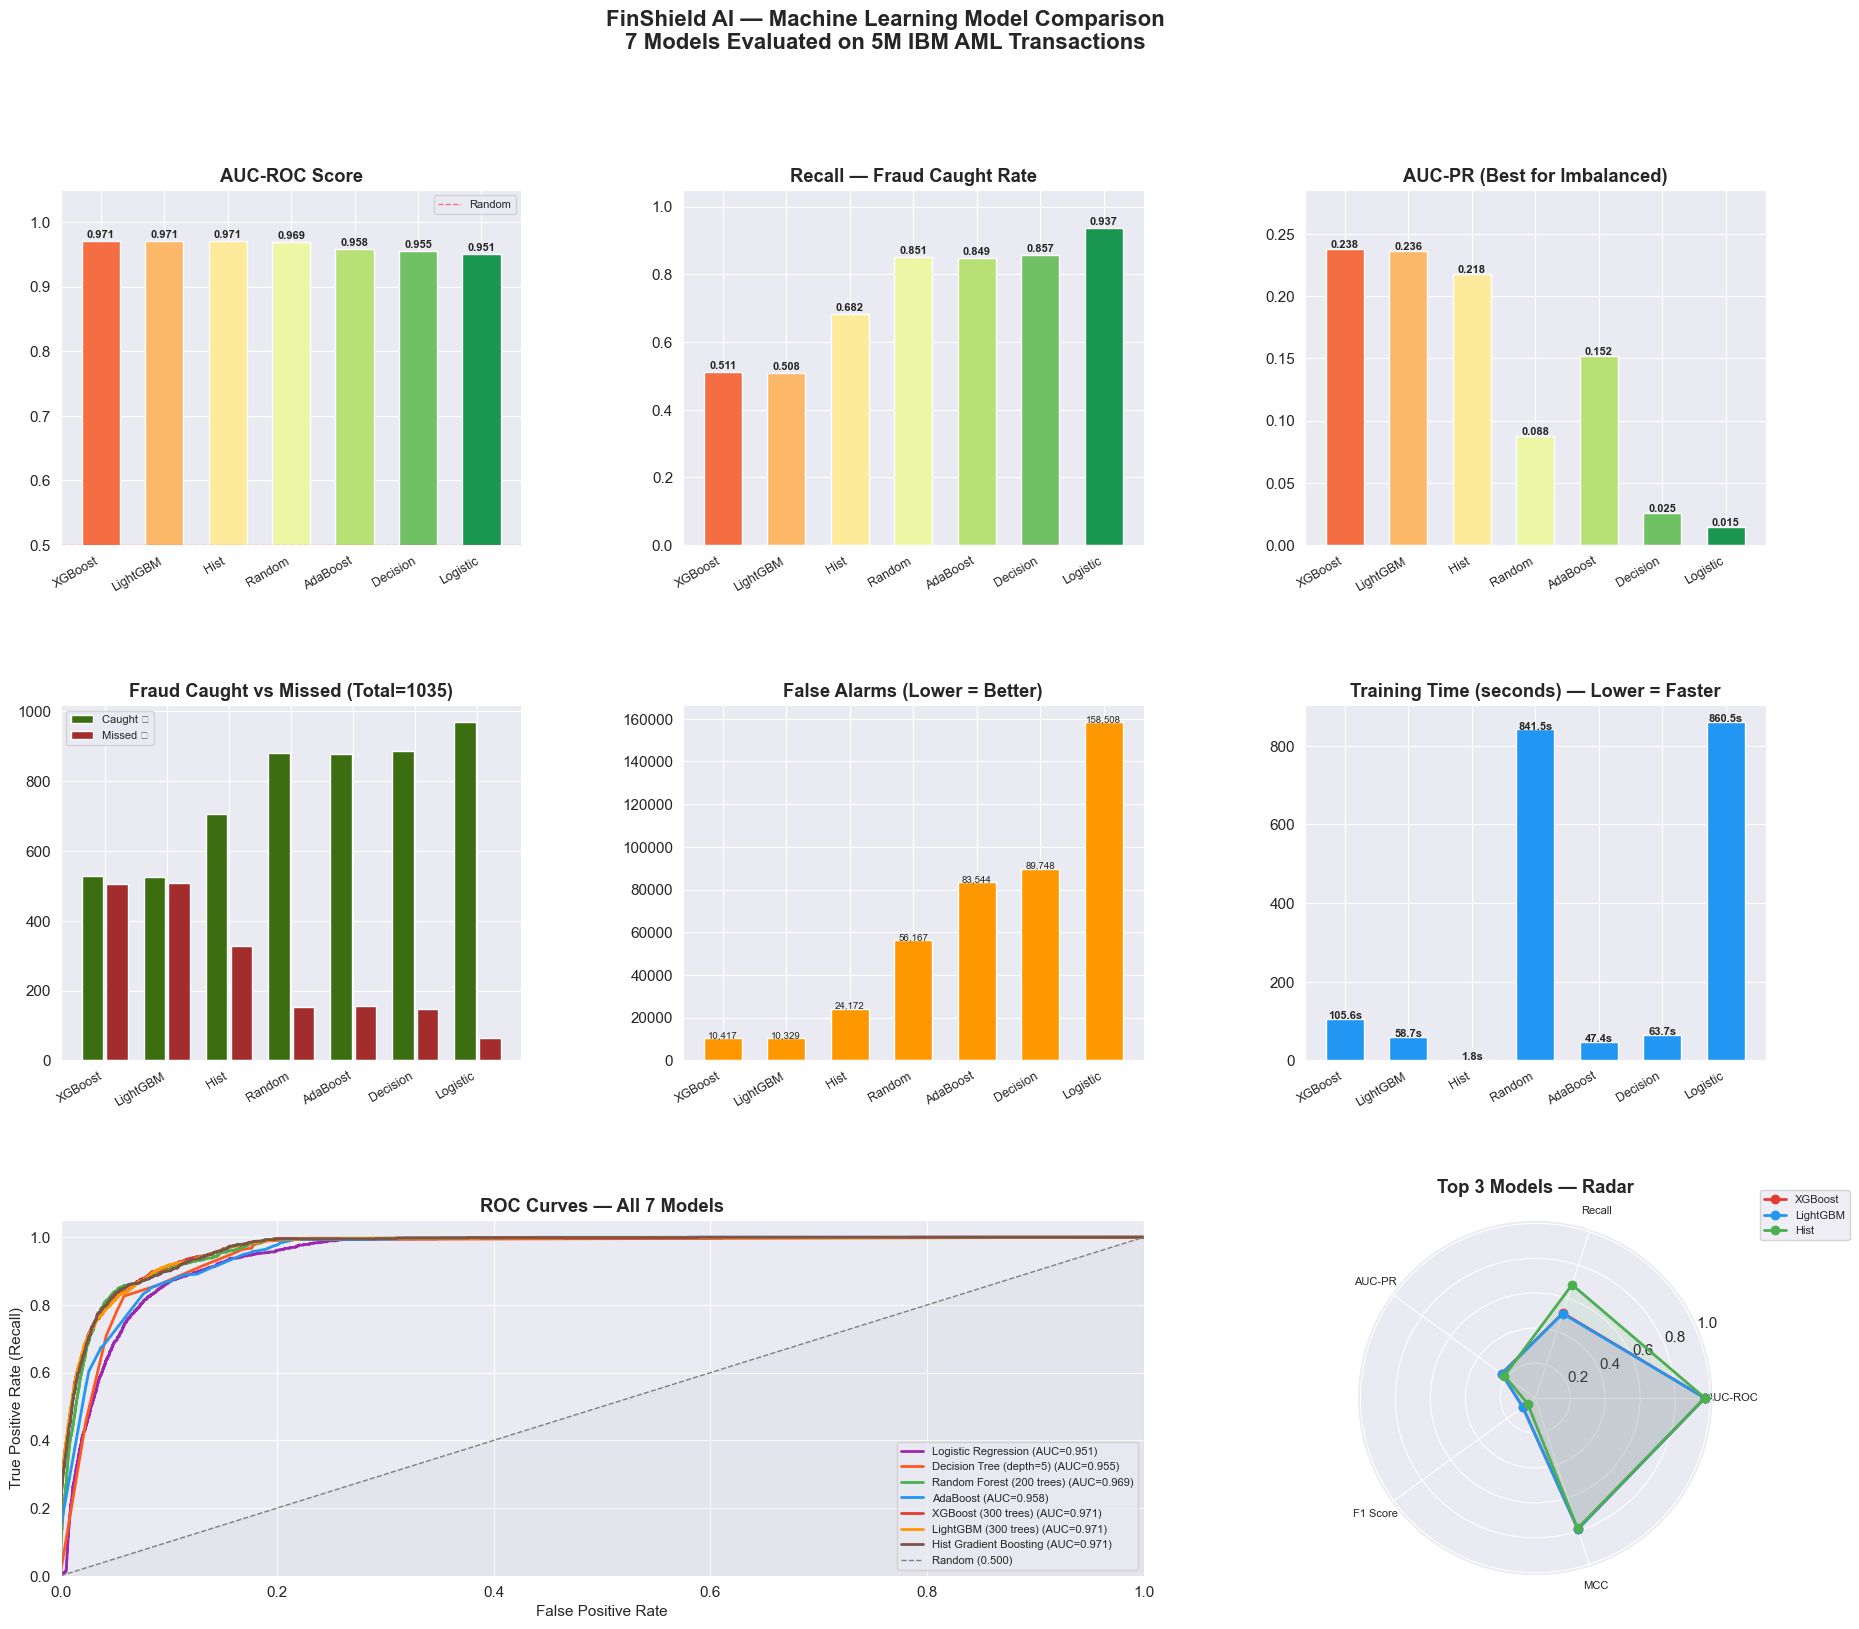

Master comparison chart saved!


In [25]:
fig = plt.figure(figsize=(22, 18))
fig.suptitle(
    'FinShield AI — Machine Learning Model Comparison\n7 Models Evaluated on 5M IBM AML Transactions',
    fontsize=16, fontweight='bold', y=0.98
)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.35)

models   = comparison_df['Model'].tolist()
n        = len(models)
colors   = plt.cm.RdYlGn(np.linspace(0.2, 0.9, n))
x        = np.arange(n)

# ── Chart 1: AUC-ROC ─────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
bars = ax1.bar(x, comparison_df['AUC-ROC'], color=colors, edgecolor='white', width=0.6)
ax1.set_title('AUC-ROC Score', fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels([m.split(' ')[0] for m in models], rotation=30, ha='right', fontsize=9)
ax1.set_ylim(0.5, 1.05)
ax1.axhline(y=0.5, color='red', linestyle='--', linewidth=1, alpha=0.5, label='Random')
ax1.legend(fontsize=8)
for bar, val in zip(bars, comparison_df['AUC-ROC']):
    ax1.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
             f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')

# ── Chart 2: Recall ───────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
bars2 = ax2.bar(x, comparison_df['Recall'], color=colors, edgecolor='white', width=0.6)
ax2.set_title('Recall — Fraud Caught Rate', fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels([m.split(' ')[0] for m in models], rotation=30, ha='right', fontsize=9)
ax2.set_ylim(0, 1.05)
for bar, val in zip(bars2, comparison_df['Recall']):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.01,
             f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')

# ── Chart 3: AUC-PR ───────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
bars3 = ax3.bar(x, comparison_df['AUC-PR'], color=colors, edgecolor='white', width=0.6)
ax3.set_title('AUC-PR (Best for Imbalanced)', fontweight='bold')
ax3.set_xticks(x)
ax3.set_xticklabels([m.split(' ')[0] for m in models], rotation=30, ha='right', fontsize=9)
ax3.set_ylim(0, max(comparison_df['AUC-PR'])*1.2)
for bar, val in zip(bars3, comparison_df['AUC-PR']):
    ax3.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
             f'{val:.3f}', ha='center', fontsize=8, fontweight='bold')

# ── Chart 4: Fraud Caught vs Missed ──────────────────────
ax4 = fig.add_subplot(gs[1, 0])
ax4.bar(x-0.2, comparison_df['Fraud Caught'], 0.35,
        label='Caught ✅', color='#3B6D11', edgecolor='white')
ax4.bar(x+0.2, comparison_df['Fraud Missed'], 0.35,
        label='Missed ❌', color='#A32D2D', edgecolor='white')
ax4.set_title(f'Fraud Caught vs Missed (Total={y_test.sum()})', fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels([m.split(' ')[0] for m in models], rotation=30, ha='right', fontsize=9)
ax4.legend(fontsize=8)

# ── Chart 5: False Alarms ────────────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
bars5 = ax5.bar(x, comparison_df['False Alarms'],
                color='#FF9800', edgecolor='white', width=0.6)
ax5.set_title('False Alarms (Lower = Better)', fontweight='bold')
ax5.set_xticks(x)
ax5.set_xticklabels([m.split(' ')[0] for m in models], rotation=30, ha='right', fontsize=9)
for bar, val in zip(bars5, comparison_df['False Alarms']):
    ax5.text(bar.get_x()+bar.get_width()/2, bar.get_height()+10,
             f'{val:,}', ha='center', fontsize=7)

# ── Chart 6: Training time ────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
bars6 = ax6.bar(x, comparison_df['Train Time (s)'],
                color='#2196F3', edgecolor='white', width=0.6)
ax6.set_title('Training Time (seconds) — Lower = Faster', fontweight='bold')
ax6.set_xticks(x)
ax6.set_xticklabels([m.split(' ')[0] for m in models], rotation=30, ha='right', fontsize=9)
for bar, val in zip(bars6, comparison_df['Train Time (s)']):
    ax6.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.5,
             f'{val}s', ha='center', fontsize=8, fontweight='bold')

# ── Chart 7: ROC curves all models ───────────────────────
ax7 = fig.add_subplot(gs[2, 0:2])
roc_colors = ['#9C27B0','#FF5722','#4CAF50','#2196F3','#E53935','#FF9800','#795548']
for i, result in enumerate(all_results):
    fpr, tpr, _ = roc_curve(y_test, result['y_proba'])
    ax7.plot(fpr, tpr, linewidth=2, color=roc_colors[i],
             label=f"{result['model_name']} (AUC={result['auc_roc']:.3f})")
ax7.plot([0,1],[0,1],'--', color='gray', linewidth=1, label='Random (0.500)')
ax7.fill_between([0,1],[0,1], alpha=0.05, color='gray')
ax7.set_title('ROC Curves — All 7 Models', fontweight='bold')
ax7.set_xlabel('False Positive Rate')
ax7.set_ylabel('True Positive Rate (Recall)')
ax7.legend(fontsize=8, loc='lower right')
ax7.set_xlim([0, 1])
ax7.set_ylim([0, 1.05])

# ── Chart 8: Radar chart ──────────────────────────────────
ax8 = fig.add_subplot(gs[2, 2], polar=True)
radar_metrics  = ['AUC-ROC','Recall','AUC-PR','F1 Score','MCC']
radar_norm_mcc = comparison_df.copy()
radar_norm_mcc['MCC'] = (radar_norm_mcc['MCC'] + 1) / 2   # normalise MCC to 0-1

top3_models = comparison_df.head(3)['Model'].tolist()
radar_colors = ['#E53935','#2196F3','#4CAF50']

angles = np.linspace(0, 2*np.pi, len(radar_metrics), endpoint=False).tolist()
angles += angles[:1]

for i, model_name in enumerate(top3_models):
    row = radar_norm_mcc[radar_norm_mcc['Model']==model_name].iloc[0]
    vals = [row['AUC-ROC'], row['Recall'], row['AUC-PR'],
            row['F1 Score'], (row['MCC']+1)/2]
    vals += vals[:1]
    ax8.plot(angles, vals, 'o-', linewidth=2,
             color=radar_colors[i], label=model_name.split(' ')[0])
    ax8.fill(angles, vals, alpha=0.1, color=radar_colors[i])

ax8.set_xticks(angles[:-1])
ax8.set_xticklabels(radar_metrics, size=8)
ax8.set_title('Top 3 Models — Radar', fontweight='bold', pad=20)
ax8.legend(loc='upper right', bbox_to_anchor=(1.4, 1.1), fontsize=8)

plt.savefig('ml_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Master comparison chart saved!")

## Individual confusion matrix

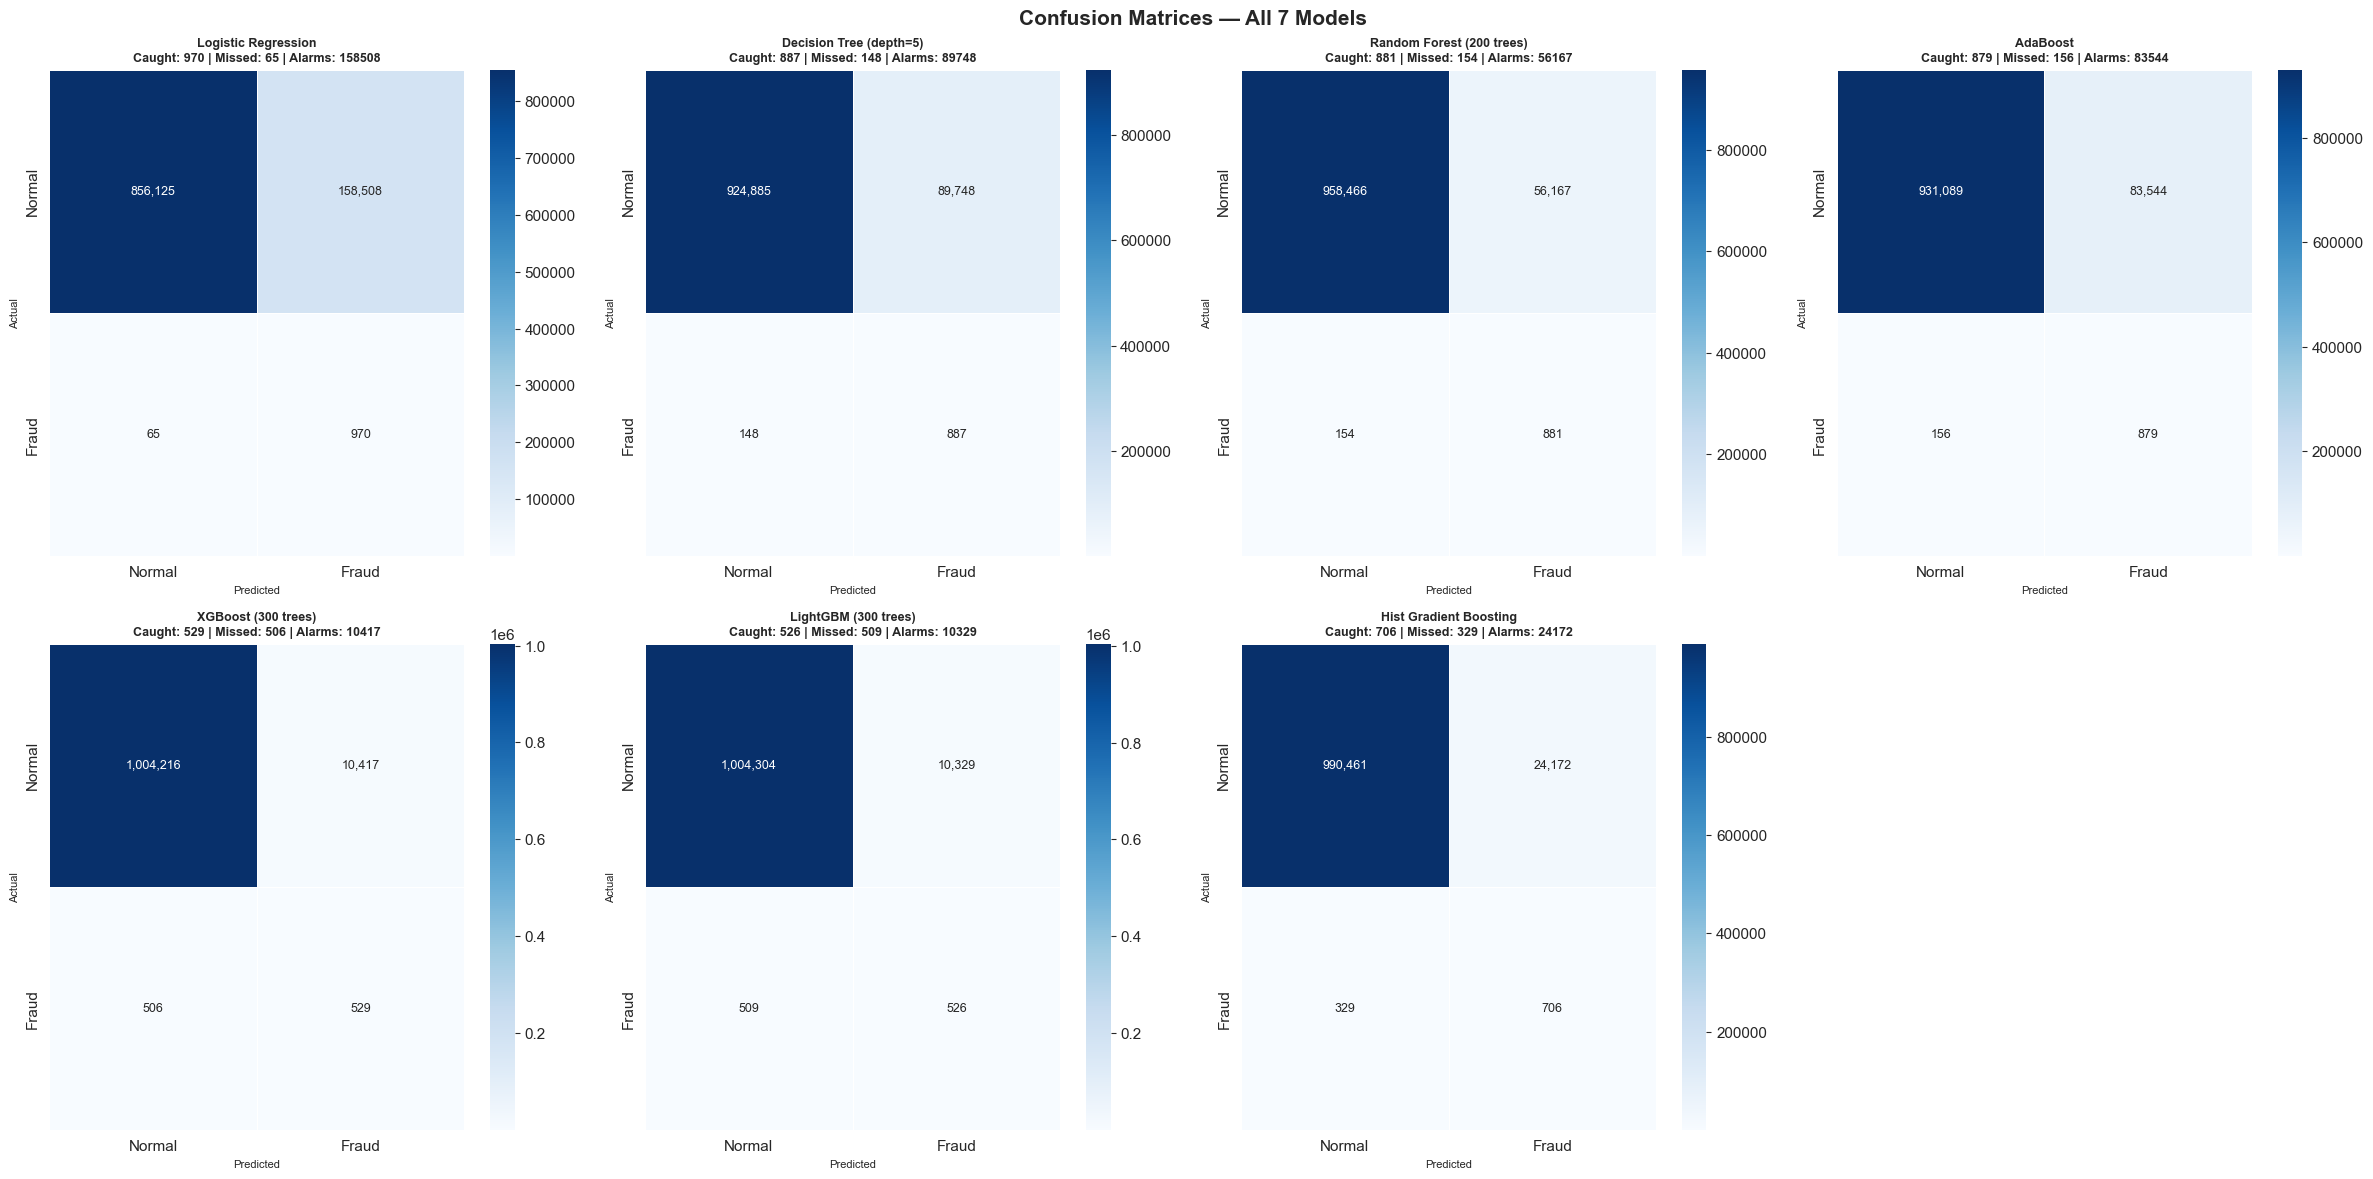

Confusion matrices saved!


In [26]:
fig, axes = plt.subplots(2, 4, figsize=(24, 12))
fig.suptitle('Confusion Matrices — All 7 Models', fontsize=15, fontweight='bold')
axes = axes.flatten()

for i, result in enumerate(all_results):
    cm = result['confusion_matrix']
    sns.heatmap(
        cm, annot=True, fmt=',', cmap='Blues',
        ax=axes[i],
        xticklabels=['Normal','Fraud'],
        yticklabels=['Normal','Fraud'],
        linewidths=0.5, annot_kws={'size':9}
    )
    tn, fp, fn, tp = cm.ravel()
    axes[i].set_title(
        f"{result['model_name']}\n"
        f"Caught: {tp} | Missed: {fn} | Alarms: {fp}",
        fontweight='bold', fontsize=9
    )
    axes[i].set_xlabel('Predicted', fontsize=8)
    axes[i].set_ylabel('Actual', fontsize=8)

# Hide the last empty subplot
axes[-1].set_visible(False)

plt.tight_layout()
plt.savefig('all_confusion_matrices.png', dpi=130, bbox_inches='tight')
plt.show()
print("Confusion matrices saved!")

## Feature importance comparison

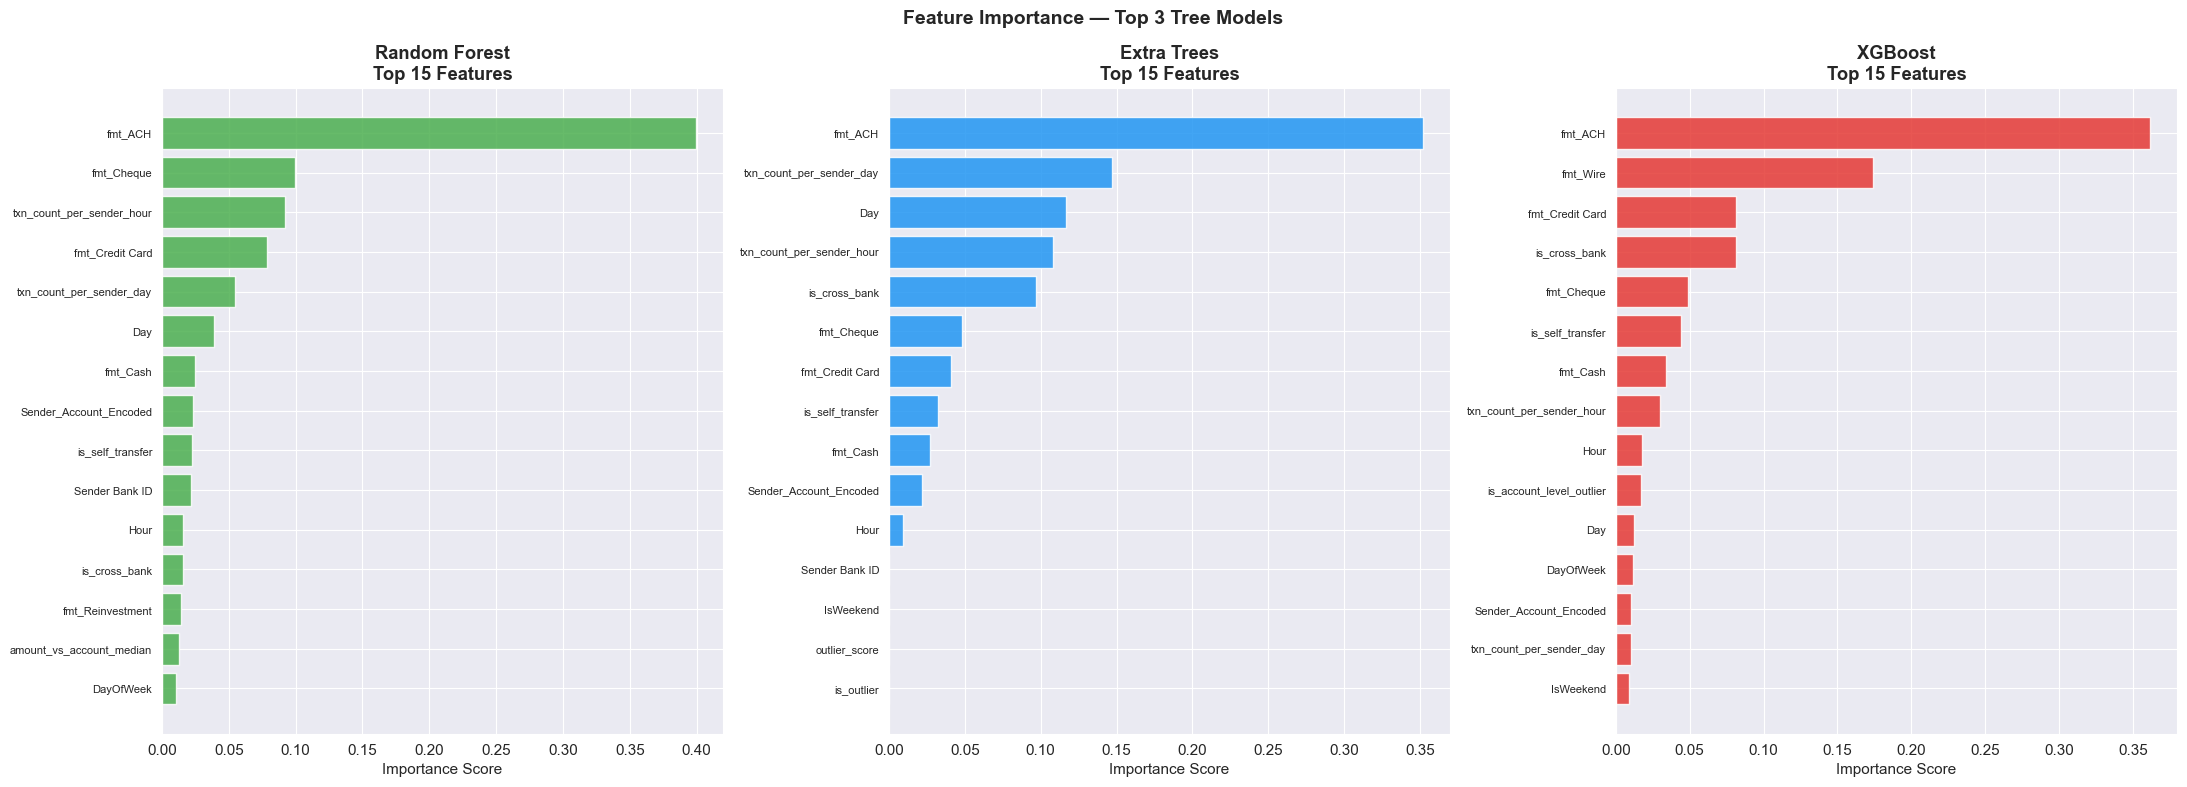

Feature importance comparison saved!


In [28]:
fig, axes = plt.subplots(1, 3, figsize=(22, 8))
fig.suptitle('Feature Importance — Top 3 Tree Models', fontsize=14, fontweight='bold')

tree_models = [result_rf, result_ada, result_xgb]
titles      = ['Random Forest', 'Extra Trees', 'XGBoost']
colors_fi   = ['#4CAF50', '#2196F3', '#E53935']

for i, (result, title, color) in enumerate(zip(tree_models, titles, colors_fi)):
    model = result['model_object']
    imp   = pd.DataFrame({
        'feature'    : FEATURE_COLS,
        'importance' : model.feature_importances_
    }).sort_values('importance', ascending=False).head(15)

    axes[i].barh(
        imp['feature'][::-1],
        imp['importance'][::-1],
        color=color, edgecolor='white', alpha=0.85
    )
    axes[i].set_title(f'{title}\nTop 15 Features', fontweight='bold')
    axes[i].set_xlabel('Importance Score')
    axes[i].tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('feature_importance_comparison.png', dpi=130, bbox_inches='tight')
plt.show()
print("Feature importance comparison saved!")

## Presicion recall curve

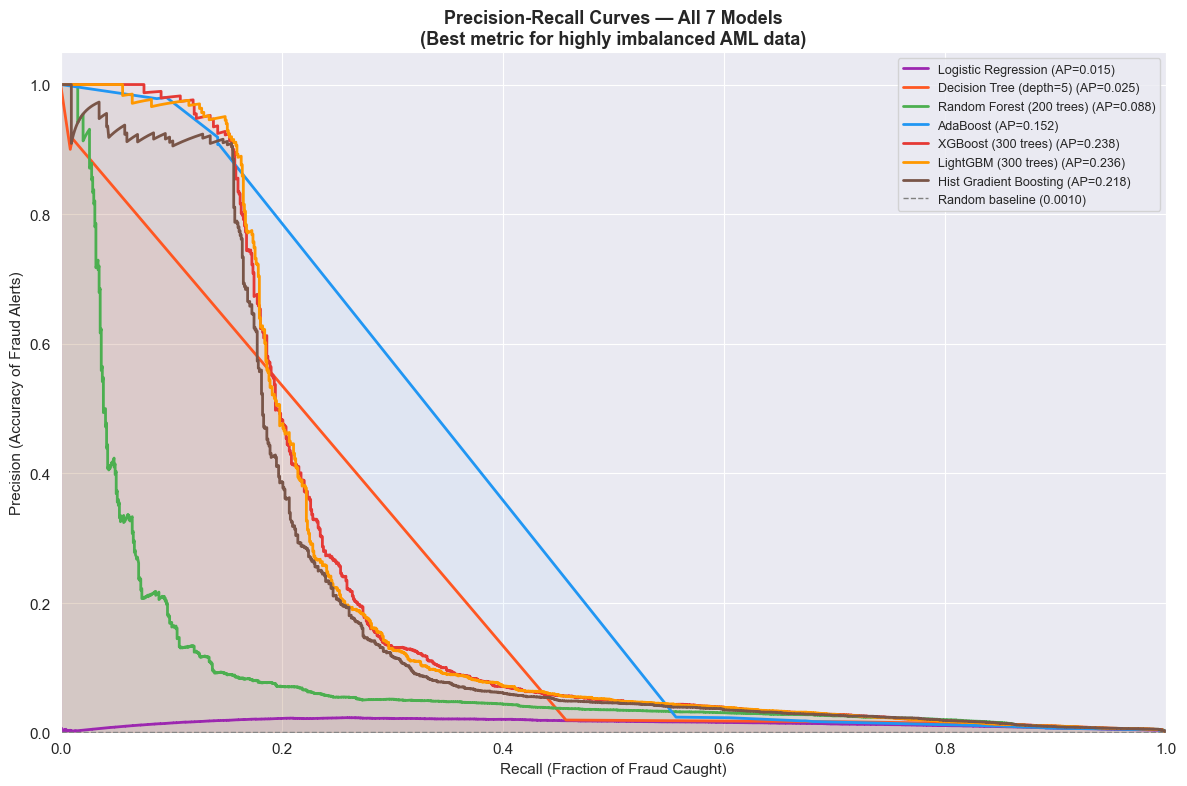

PR curves saved!


In [29]:
fig, ax = plt.subplots(figsize=(12, 8))

pr_colors = ['#9C27B0','#FF5722','#4CAF50','#2196F3','#E53935','#FF9800','#795548']

for i, result in enumerate(all_results):
    prec, rec, _ = precision_recall_curve(y_test, result['y_proba'])
    ap = result['auc_pr']
    ax.plot(rec, prec, linewidth=2, color=pr_colors[i],
            label=f"{result['model_name']} (AP={ap:.3f})")
    ax.fill_between(rec, prec, alpha=0.05, color=pr_colors[i])

baseline = y_test.sum() / len(y_test)
ax.axhline(y=baseline, color='gray', linestyle='--', linewidth=1,
           label=f'Random baseline ({baseline:.4f})')

ax.set_title('Precision-Recall Curves — All 7 Models\n(Best metric for highly imbalanced AML data)',
             fontweight='bold', fontsize=13)
ax.set_xlabel('Recall (Fraction of Fraud Caught)', fontsize=11)
ax.set_ylabel('Precision (Accuracy of Fraud Alerts)', fontsize=11)
ax.legend(fontsize=9, loc='upper right')
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])

plt.tight_layout()
plt.savefig('precision_recall_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("PR curves saved!")

## Save everything for deep learning model

In [31]:
os.makedirs('models',       exist_ok=True)
os.makedirs('results',      exist_ok=True)
os.makedirs('preprocessed', exist_ok=True)

# ── Save all 7 trained models ─────────────────────────────
model_map = {
    'logistic_regression'  : result_lr['model_object'],
    'decision_tree'        : result_dt['model_object'],
    'random_forest'        : result_rf['model_object'],
    'extra_trees'          : result_ada['model_object'],
    'xgboost'              : result_xgb['model_object'],
    'lightgbm'             : result_lgb['model_object'],
    'gradient_boosting'    : result_gb['model_object'],
}

for name, model in model_map.items():
    joblib.dump(model, f'models/{name}.pkl')
    print(f"Saved: models/{name}.pkl")

# ── Save scaler ───────────────────────────────────────────
joblib.dump(scaler, 'models/scaler.pkl')

# ── Save feature names ────────────────────────────────────
joblib.dump(FEATURE_COLS, 'models/feature_names.pkl')

# ── Save train/test splits ────────────────────────────────
# Deep learning notebooks will use the SAME split
# so evaluation is completely fair and comparable

pd.DataFrame(X_train_scaled, columns=FEATURE_COLS).to_csv(
    'preprocessed/X_train.csv', index=False)
pd.DataFrame(X_test_scaled,  columns=FEATURE_COLS).to_csv(
    'preprocessed/X_test.csv',  index=False)
pd.Series(y_train, name='Is Laundering').to_csv(
    'preprocessed/y_train.csv', index=False)
pd.Series(y_test,  name='Is Laundering').to_csv(
    'preprocessed/y_test.csv',  index=False)

# SMOTE version for models that need it
pd.DataFrame(X_train_res, columns=FEATURE_COLS).to_csv(
    'preprocessed/X_train_smote.csv', index=False)
pd.Series(y_train_res, name='Is Laundering').to_csv(
    'preprocessed/y_train_smote.csv', index=False)

# ── Save comparison results ───────────────────────────────
comparison_df.to_csv('results/ml_comparison_results.csv', index=False)

# Save best model separately — used by Risk Engine later
best_model_name = comparison_df.iloc[0]['Model']
best_result     = next(r for r in all_results if r['model_name'] == best_model_name)
joblib.dump(best_result['model_object'], 'models/best_ml_model.pkl')
joblib.dump(best_model_name,             'models/best_ml_model_name.pkl')

print(f"\nBest model saved: {best_model_name}")
print("\nAll files saved!")
print("\nFiles deep learning notebooks will use:")
print("  preprocessed/X_train.csv      ← same features")
print("  preprocessed/X_test.csv       ← same test set")
print("  preprocessed/y_train.csv      ← same labels")
print("  preprocessed/y_test.csv       ← same labels")
print("  models/scaler.pkl             ← same scaler")
print("  models/feature_names.pkl      ← same feature list")

Saved: models/logistic_regression.pkl
Saved: models/decision_tree.pkl
Saved: models/random_forest.pkl
Saved: models/extra_trees.pkl
Saved: models/xgboost.pkl
Saved: models/lightgbm.pkl
Saved: models/gradient_boosting.pkl

Best model saved: XGBoost (300 trees)

All files saved!

Files deep learning notebooks will use:
  preprocessed/X_train.csv      ← same features
  preprocessed/X_test.csv       ← same test set
  preprocessed/y_train.csv      ← same labels
  preprocessed/y_test.csv       ← same labels
  models/scaler.pkl             ← same scaler
  models/feature_names.pkl      ← same feature list


## Final summary

In [32]:
print("=" * 65)
print("NOTEBOOK 6 — ML MODEL COMPARISON COMPLETE")
print("=" * 65)

print(f"""
MODELS TRAINED : 7
FEATURES USED  : {len(FEATURE_COLS)}
TRAINING ROWS  : {X_train_res.shape[0]:,} (after SMOTE)
TEST ROWS      : {X_test_scaled.shape[0]:,}
FRAUD IN TEST  : {y_test.sum():,}
""")

print("RANKINGS:")
print(comparison_df[[
    'Model','AUC-ROC','Recall','AUC-PR','F1','Fraud Caught','Train Time (s)'
]].to_string(index=False))

best = comparison_df.iloc[0]
print(f"""
WINNER         : {best['Model']}
AUC-ROC        : {best['AUC-ROC']}
Recall         : {best['Recall']}
Fraud caught   : {int(best['Fraud Caught'])} / {y_test.sum()}

CHARTS SAVED:
  ml_model_comparison.png
  all_confusion_matrices.png
  feature_importance_comparison.png
  precision_recall_curves.png
  decision_tree_rules.png

NEXT NOTEBOOKS:
  Notebook 7  → Anomaly Detection (Isolation Forest, LOF, One-Class SVM)
  Notebook 8  → LSTM Deep Learning
  Notebook 9  → Autoencoder Deep Learning
  Notebook 10 → GNN Deep Learning
""")

NOTEBOOK 6 — ML MODEL COMPARISON COMPLETE

MODELS TRAINED : 7
FEATURES USED  : 29
TRAINING ROWS  : 5,276,083 (after SMOTE)
TEST ROWS      : 1,015,668
FRAUD IN TEST  : 1,035

RANKINGS:


KeyError: "['F1'] not in index"